In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="white", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 16,
    "axes.grid": False,
})

In [ ]:
FILE_PATH = "/Users/saranya.pal/Desktop/float-categorisation/data/preprocessed_training_data_numerical.csv"
df = pd.read_csv(FILE_PATH)
df.shape

(3078, 25)

## Feature Derivation Reference

The preprocessed training data is produced by `FeatureProcessor` and `TextProcessor` in the pipeline. Below is a summary of every feature, how it was derived, and which original CSV column it comes from.

### Original CSV Columns (Raw Data)
`Date`, `Transaction Type`, `Payee`, `Amount`, `Currency`, `Account`, `Initial Amount`, `Initial Currency`, `Transaction Detail`, `Spender`, `Last 4 digits`, `Funding Account`, `Approver`, `Payment Authorizer`, `Invoice Number`, `FX Initial Amount`, `FX Initial Currency`, `Conversion Rate`, `GL Code`

---

### Feature Derivation Table

| # | Preprocessed Feature | Type | Source Column(s) | Derivation Method |
|---|---|---|---|---|
| 1 | `spender` | int | `Spender` | **Derived** — Person name normalised (lowercased, whitespace collapsed) then mapped to an integer ID via a fixed dictionary (`NAME_TO_ID`). Null → 0, unknown name → 18. |
| 2 | `approver` | int | `Approver` | **Derived** — Same name-to-ID encoding as `spender`. |
| 3 | `payment authorizer` | int | `Payment Authorizer` | **Derived** — Same name-to-ID encoding as `spender`. |
| 4 | `amount_parsed` | float | `Amount` | **Derived** — Raw string parsed: parentheses `(…)` → negative, commas stripped, cast to float. |
| 5 | `month` | int | `Date` | **Derived** — Extracted via `pd.to_datetime(date).dt.month`. Range 1–12. |
| 6 | `day_of_week` | int | `Date` | **Derived** — Extracted via `pd.to_datetime(date).dt.dayofweek`. 0 = Monday … 6 = Sunday. |
| 7 | `payee_encoded` | int | `Payee` | **Derived** — Payee normalised (uppercased, reference IDs stripped), then hashed with `MD5 mod 10 000` for a stable integer. |
| 8 | `payee_k_travel` | binary | `Payee` | **Derived** — 1 if payee matches travel-related regex (hotels, airlines, rental cars, airports, etc.), else 0. |
| 9 | `payee_k_food` | binary | `Payee` | **Derived** — 1 if payee matches food/restaurant regex (cafes, delivery apps, restaurants, etc.), else 0. |
| 10 | `payee_k_software` | binary | `Payee` | **Derived** — 1 if payee matches software/SaaS regex (AWS, GitHub, Slack, Zoom, etc.), else 0. |
| 11 | `payee_k_amazon` | binary | `Payee` | **Derived** — 1 if payee matches `amazon\|amzn`, else 0. |
| 12 | `account_is_null` | binary | `Account` | **Primary** — 1 if the `Account` field was null/missing, else 0. *(Constant = 0 in this dataset.)* |
| 13 | `initial amount_is_null` | binary | `Initial Amount` | **Primary** — 1 if `Initial Amount` was null, else 0. |
| 14 | `initial currency_is_null` | binary | `Initial Currency` | **Primary** — 1 if `Initial Currency` was null, else 0. *(Constant = 0.)* |
| 15 | `last 4 digits_is_null` | binary | `Last 4 digits` | **Primary** — 1 if `Last 4 digits` was null, else 0. *(Constant = 0.)* |
| 16 | `invoice number_is_null` | binary | `Invoice Number` | **Primary** — 1 if `Invoice Number` was null, else 0. *(Constant = 0.)* |
| 17 | `fx initial currency_is_null` | binary | `FX Initial Currency` | **Primary** — 1 if `FX Initial Currency` was null, else 0. *(Constant = 0.)* |
| 18 | `fx initial amount_is_null` | binary | `FX Initial Amount` | **Primary** — 1 if `FX Initial Amount` was null, else 0. *(Constant = 1.)* |
| 19 | `conversion rate_is_null` | binary | `Conversion Rate` | **Primary** — 1 if `Conversion Rate` was null, else 0. |
| 20 | `detail_is_null` | binary | `Transaction Detail` | **Primary** — 1 if `Transaction Detail` was null, else 0. *(Constant = 0.)* |
| 21 | `transaction type_bill payment` | binary | `Transaction Type` | **Derived** — One-hot encoding of `Transaction Type`. 1 if type = "bill payment". |
| 22 | `transaction type_purchase` | binary | `Transaction Type` | **Derived** — One-hot encoding. 1 if type = "purchase". |
| 23 | `transaction type_refund` | binary | `Transaction Type` | **Derived** — One-hot encoding. 1 if type = "refund". |
| 24 | `aggregated_text` | text | `Transaction Type`, `Payee`, `Transaction Detail` | **Derived** — Each text column cleaned via spaCy (lemmatised, stopwords & punctuation removed), then all three joined into a single space-separated string. |
| 25 | `gl_code` | text | `GL Code` | **Target** — GL code label, cleaned with the same spaCy pipeline (lemmatised). |

> **Primary** = value taken directly from the presence/absence of a raw column (null-check).
> **Derived** = computed via transformation, encoding, regex, parsing, or NLP on one or more raw columns.

# Preprocessed Training Data — Final Pipeline Analysis

## Assumptions
1. **Data reflects the ML branch only**: The preprocessed training data contains rows that were *not* captured by the deterministic (fuzzy-rule) classifier. GL codes like `5615 facebook advertising`, `5690 interest bank charge`, etc., are handled by rules and are excluded here.
2. **All features are already encoded numerically** by `FeatureProcessor`:  
   - Name-based columns (`spender`, `approver`, `payment authorizer`) are integer IDs (0 = unknown/none, 1–17 = known persons, 18 = unknown).  
   - `payee_encoded` is an MD5-hash-based integer (not ordinal — treat as a high-cardinality categorical).  
   - Binary flags (keyword flags, null-indicator flags, one-hot transaction types) are 0/1.  
   - `amount_parsed` is the only truly continuous numerical feature.  
   - `month` (1–12) and `day_of_week` (0–6) are discrete ordinal features.
3. **TF-IDF features are excluded** from this analysis — they are generated at training time and not stored in this CSV (only `aggregated_text` is present).
4. **Target variable** is `gl_code` — a multi-class categorical label (11 classes in this dataset).
5. **Class imbalance is expected** because some GL codes are naturally rarer in non-deterministic transactions.

In [3]:
# ── Feature categorisation ──────────────────────────────────────────────────
CONTINUOUS_FEATURES  = ["amount_parsed"]
ORDINAL_FEATURES     = ["month", "day_of_week"]
ENCODED_ID_FEATURES  = ["spender", "approver", "payment authorizer"]
HASH_FEATURES        = ["payee_encoded"]

BINARY_KEYWORD_FLAGS = ["payee_k_travel", "payee_k_food", "payee_k_software", "payee_k_amazon"]
BINARY_NULL_FLAGS    = [
    "initial amount_is_null", "conversion rate_is_null",
]
BINARY_TXN_TYPE      = ["transaction type_bill payment", "transaction type_purchase", "transaction type_refund"]

# Columns that are constant in this dataset (zero variance) — noted for completeness
CONSTANT_COLS = [
    "account_is_null", "initial currency_is_null", "last 4 digits_is_null",
    "invoice number_is_null", "fx initial currency_is_null",
    "fx initial amount_is_null", "detail_is_null",
]

BINARY_FEATURES = BINARY_KEYWORD_FLAGS + BINARY_NULL_FLAGS + BINARY_TXN_TYPE
ALL_NUMERIC     = CONTINUOUS_FEATURES + ORDINAL_FEATURES + ENCODED_ID_FEATURES + HASH_FEATURES + BINARY_FEATURES
TARGET          = "gl_code"

print(f"Continuous features  ({len(CONTINUOUS_FEATURES)}): {CONTINUOUS_FEATURES}")
print(f"Ordinal features     ({len(ORDINAL_FEATURES)}): {ORDINAL_FEATURES}")
print(f"Encoded-ID features  ({len(ENCODED_ID_FEATURES)}): {ENCODED_ID_FEATURES}")
print(f"Hash features        ({len(HASH_FEATURES)}): {HASH_FEATURES}")
print(f"Binary features      ({len(BINARY_FEATURES)}): {BINARY_FEATURES}")
print(f"Constant (dropped)   ({len(CONSTANT_COLS)}): {CONSTANT_COLS}")
print(f"\nTotal non-constant numeric features: {len(ALL_NUMERIC)}")
print(f"Target: {TARGET}  ({df[TARGET].nunique()} classes)")

Continuous features  (1): ['amount_parsed']
Ordinal features     (2): ['month', 'day_of_week']
Encoded-ID features  (3): ['spender', 'approver', 'payment authorizer']
Hash features        (1): ['payee_encoded']
Binary features      (9): ['payee_k_travel', 'payee_k_food', 'payee_k_software', 'payee_k_amazon', 'initial amount_is_null', 'conversion rate_is_null', 'transaction type_bill payment', 'transaction type_purchase', 'transaction type_refund']
Constant (dropped)   (7): ['account_is_null', 'initial currency_is_null', 'last 4 digits_is_null', 'invoice number_is_null', 'fx initial currency_is_null', 'fx initial amount_is_null', 'detail_is_null']

Total non-constant numeric features: 16
Target: gl_code  (11 classes)


## 1. Basic Data Analysis

In [4]:
# ── Shape, types, nulls ─────────────────────────────────────────────────────
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

print("Column dtypes:")
display(df.dtypes.to_frame("dtype").T)

print("\nNull counts per column:")
display(df.isnull().sum().to_frame("nulls").T)

print("\nConstant columns (single unique value — provide no information):")
for c in CONSTANT_COLS:
    print(f"  • {c}  →  unique value = {df[c].unique()[0]}")

print("\nBasic statistics (non-constant numeric features):")
display(df[ALL_NUMERIC].describe().T.style.format("{:.2f}").background_gradient(cmap="YlOrRd", axis=0))

Dataset shape: 3078 rows × 25 columns

Column dtypes:


,spender,approver,payment authorizer,amount_parsed,month,day_of_week,payee_encoded,payee_k_travel,payee_k_food,payee_k_software,...,invoice number_is_null,fx initial currency_is_null,fx initial amount_is_null,conversion rate_is_null,detail_is_null,transaction type_bill payment,transaction type_purchase,transaction type_refund,aggregated_text,gl_code
dtype,int64,int64,int64,float64,int64,int64,int64,int64,int64,int64,...,int64,int64,int64,int64,int64,int64,int64,int64,str,str



Null counts per column:


,spender,approver,payment authorizer,amount_parsed,month,day_of_week,payee_encoded,payee_k_travel,payee_k_food,payee_k_software,...,invoice number_is_null,fx initial currency_is_null,fx initial amount_is_null,conversion rate_is_null,detail_is_null,transaction type_bill payment,transaction type_purchase,transaction type_refund,aggregated_text,gl_code
nulls,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Constant columns (single unique value — provide no information):
  • account_is_null  →  unique value = 0
  • initial currency_is_null  →  unique value = 0
  • last 4 digits_is_null  →  unique value = 0
  • invoice number_is_null  →  unique value = 0
  • fx initial currency_is_null  →  unique value = 0
  • fx initial amount_is_null  →  unique value = 1
  • detail_is_null  →  unique value = 0

Basic statistics (non-constant numeric features):


,count,mean,std,min,25%,50%,75%,max
amount_parsed,3078.00,-1949.08,15509.42,-376913.12,-208.19,-66.94,-17.91,5626.18
month,3078.00,6.95,3.26,1.00,4.00,7.00,10.00,12.00
day_of_week,3078.00,3.21,1.71,0.00,2.00,3.00,5.00,6.00
spender,3078.00,7.05,3.55,0.00,5.00,6.00,11.00,17.00
approver,3078.00,0.45,2.50,0.00,0.00,0.00,0.00,16.00
payment authorizer,3078.00,0.45,2.50,0.00,0.00,0.00,0.00,16.00
payee_encoded,3078.00,5093.91,2865.50,22.00,2569.25,5229.00,7491.00,9995.00
payee_k_travel,3078.00,0.09,0.29,0.00,0.00,0.00,0.00,1.00
payee_k_food,3078.00,0.06,0.24,0.00,0.00,0.00,0.00,1.00
payee_k_software,3078.00,0.15,0.36,0.00,0.00,0.00,0.00,1.00


## 2. Target Variable — GL Code Distribution

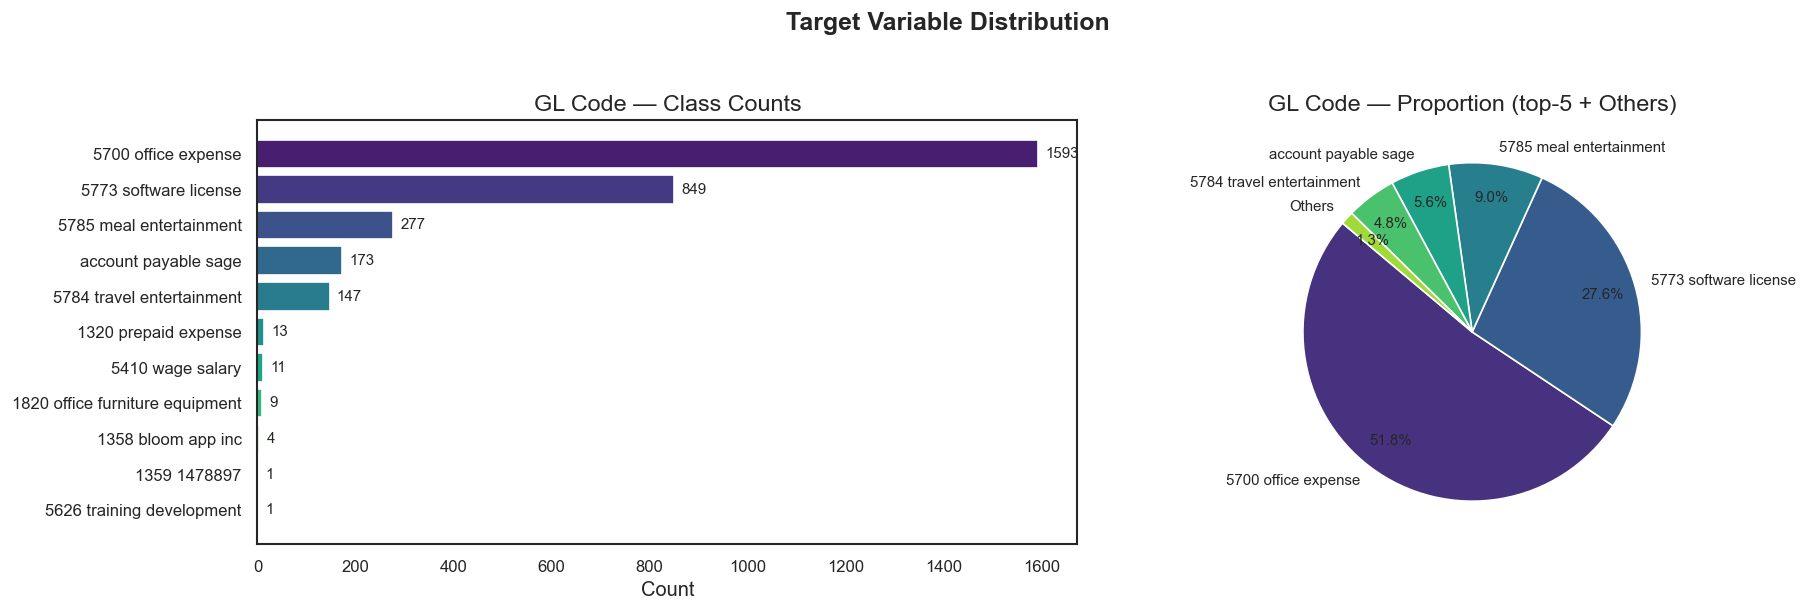


Total classes: 11
Most frequent : 5700 office expense  (1593 samples, 51.8%)
Least frequent: 5626 training development  (1 samples, 0.0%)
Imbalance ratio (max/min): 1593×


In [5]:
# ── GL code class distribution ──────────────────────────────────────────────
gl_counts = df[TARGET].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = sns.color_palette("viridis", n_colors=len(gl_counts))
bars = axes[0].barh(gl_counts.index[::-1], gl_counts.values[::-1], color=colors[::-1], edgecolor="white")
axes[0].set_xlabel("Count")
axes[0].set_title("GL Code — Class Counts")
for bar, val in zip(bars, gl_counts.values[::-1]):
    axes[0].text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
                 f"{val}", va="center", fontsize=9)

# Pie chart (top-5 + Others)
top_n = 5
top = gl_counts.head(top_n)
others = gl_counts.iloc[top_n:].sum()
pie_data = pd.concat([top, pd.Series({"Others": others})])
wedges, texts, autotexts = axes[1].pie(
    pie_data, labels=pie_data.index, autopct="%1.1f%%",
    startangle=140, colors=sns.color_palette("viridis", len(pie_data)),
    textprops={"fontsize": 9}, pctdistance=0.8,
)
axes[1].set_title("GL Code — Proportion (top-5 + Others)")

fig.suptitle("Target Variable Distribution", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nTotal classes: {len(gl_counts)}")
print(f"Most frequent : {gl_counts.index[0]}  ({gl_counts.iloc[0]} samples, {gl_counts.iloc[0]/len(df)*100:.1f}%)")
print(f"Least frequent: {gl_counts.index[-1]}  ({gl_counts.iloc[-1]} samples, {gl_counts.iloc[-1]/len(df)*100:.1f}%)")
print(f"Imbalance ratio (max/min): {gl_counts.iloc[0]/gl_counts.iloc[-1]:.0f}×")

## 3. Numerical Feature Distributions (Histogram + KDE)

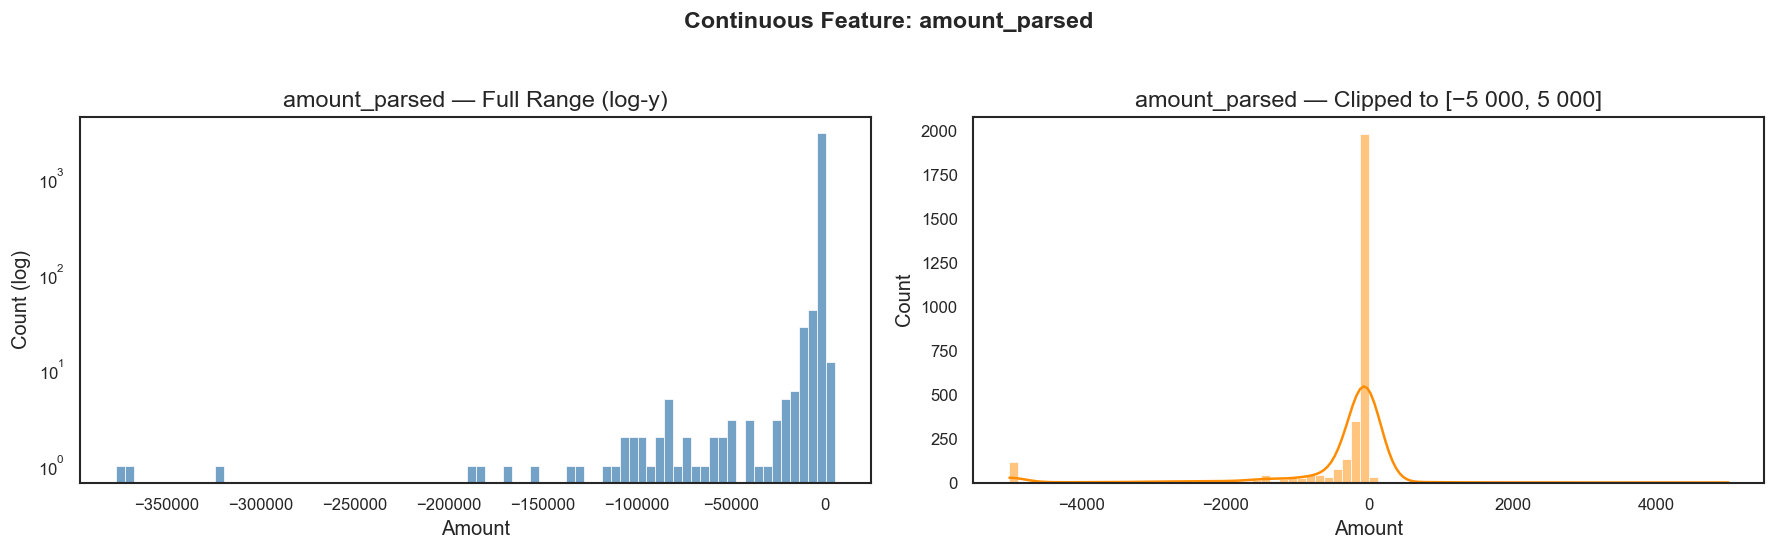

In [6]:
# ── amount_parsed — clipped histogram + KDE ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# Full distribution (log-scaled y) — no KDE (it breaks on log scale)
sns.histplot(df["amount_parsed"], bins=80, kde=False, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("amount_parsed — Full Range (log-y)")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Count (log)")

# Zoomed: clip to ±5000 for readability — KDE works fine here
clipped = df["amount_parsed"].clip(-5000, 5000)
sns.histplot(clipped, bins=80, kde=True, ax=axes[1], color="darkorange", edgecolor="white")
axes[1].set_title("amount_parsed — Clipped to [−5 000, 5 000]")
axes[1].set_xlabel("Amount")

fig.suptitle("Continuous Feature: amount_parsed", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

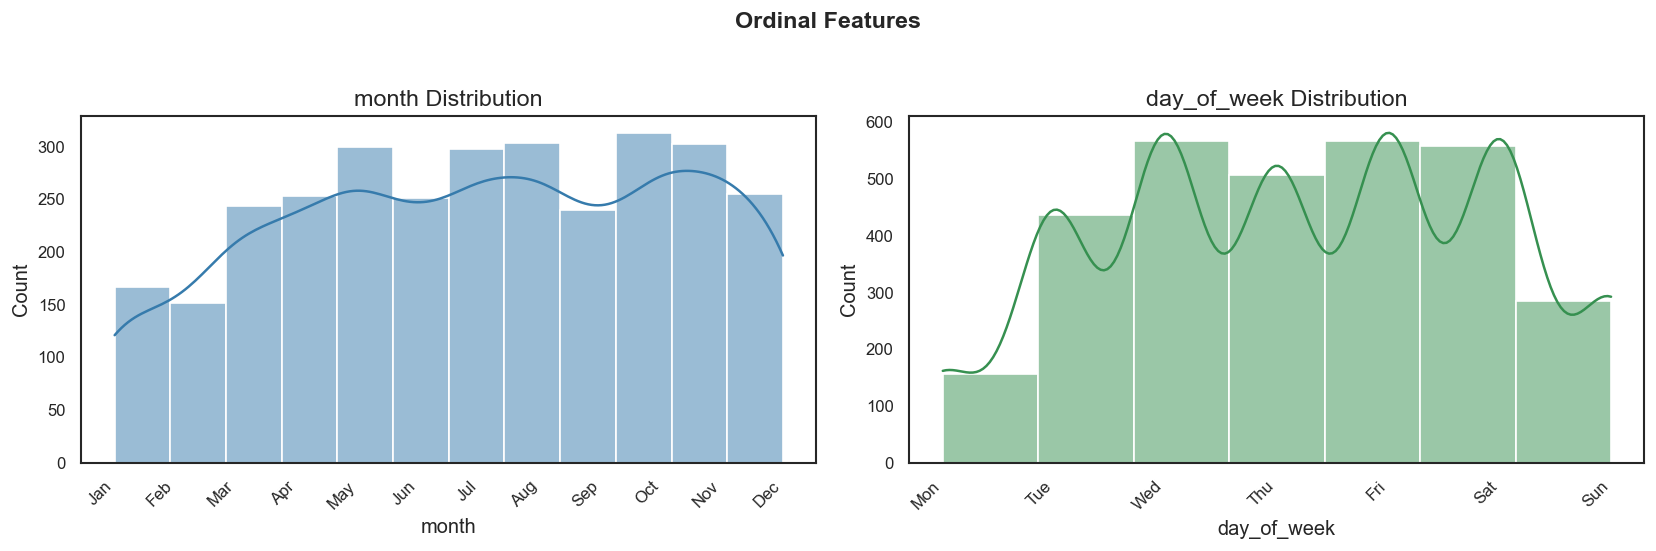

In [7]:
# ── Ordinal features: month & day_of_week — histograms with KDE ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, col, pal, xlabels in zip(
    axes,
    ["month", "day_of_week"],
    ["Blues_d", "Greens_d"],
    [
        {i: m for i, m in enumerate(["Jan","Feb","Mar","Apr","May","Jun",
                                      "Jul","Aug","Sep","Oct","Nov","Dec"], 1)},
        {i: d for i, d in enumerate(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])},
    ],
):
    sns.histplot(df[col], bins=len(xlabels), kde=True, ax=ax, color=sns.color_palette(pal)[3], edgecolor="white")
    ax.set_xticks(list(xlabels.keys()))
    ax.set_xticklabels(list(xlabels.values()), rotation=45, ha="right")
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)

fig.suptitle("Ordinal Features", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

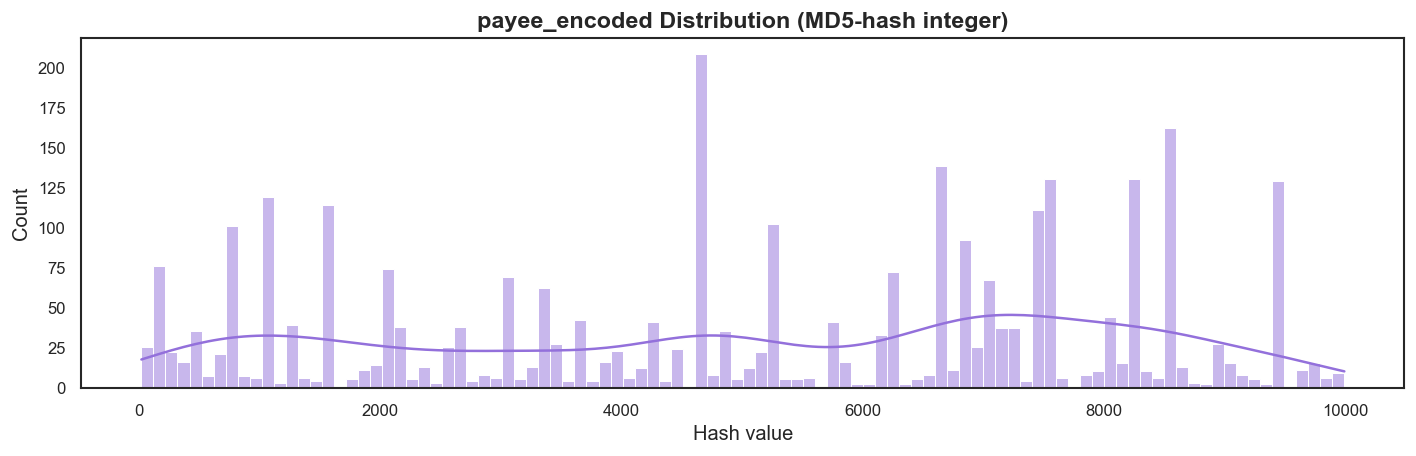

Unique payee hashes: 418 / 3078 rows


In [8]:
# ── payee_encoded distribution (hash-based — treat as high-cardinality) ────
fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(df["payee_encoded"], bins=100, kde=True, ax=ax, color="mediumpurple", edgecolor="white")
ax.set_title("payee_encoded Distribution (MD5-hash integer)", fontsize=14, fontweight="bold")
ax.set_xlabel("Hash value")
plt.tight_layout()
plt.show()
print(f"Unique payee hashes: {df['payee_encoded'].nunique()} / {len(df)} rows")

## 4. Categorical / Encoded-ID Feature Distributions (Value Counts)

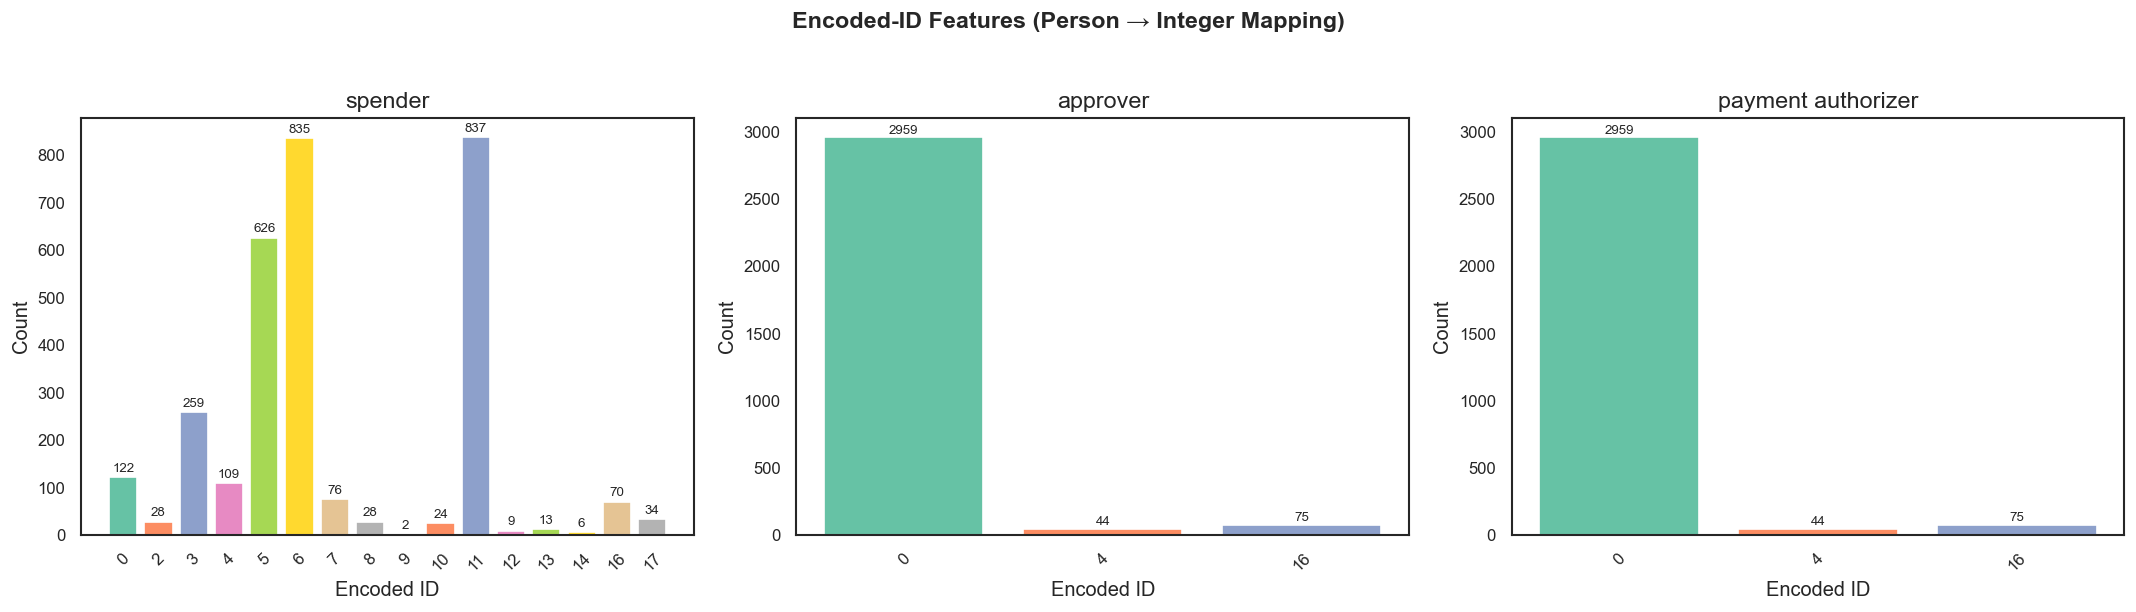

In [9]:
# ── Encoded-ID features: spender, approver, payment authorizer ──────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
id_features = ENCODED_ID_FEATURES

for ax, col in zip(axes, id_features):
    vc = df[col].value_counts().sort_index()
    bars = ax.bar(vc.index.astype(str), vc.values, color=sns.color_palette("Set2", len(vc)), edgecolor="white")
    ax.set_title(f"{col}")
    ax.set_xlabel("Encoded ID")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
    for bar, val in zip(bars, vc.values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                    str(val), ha="center", va="bottom", fontsize=8)

fig.suptitle("Encoded-ID Features (Person → Integer Mapping)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

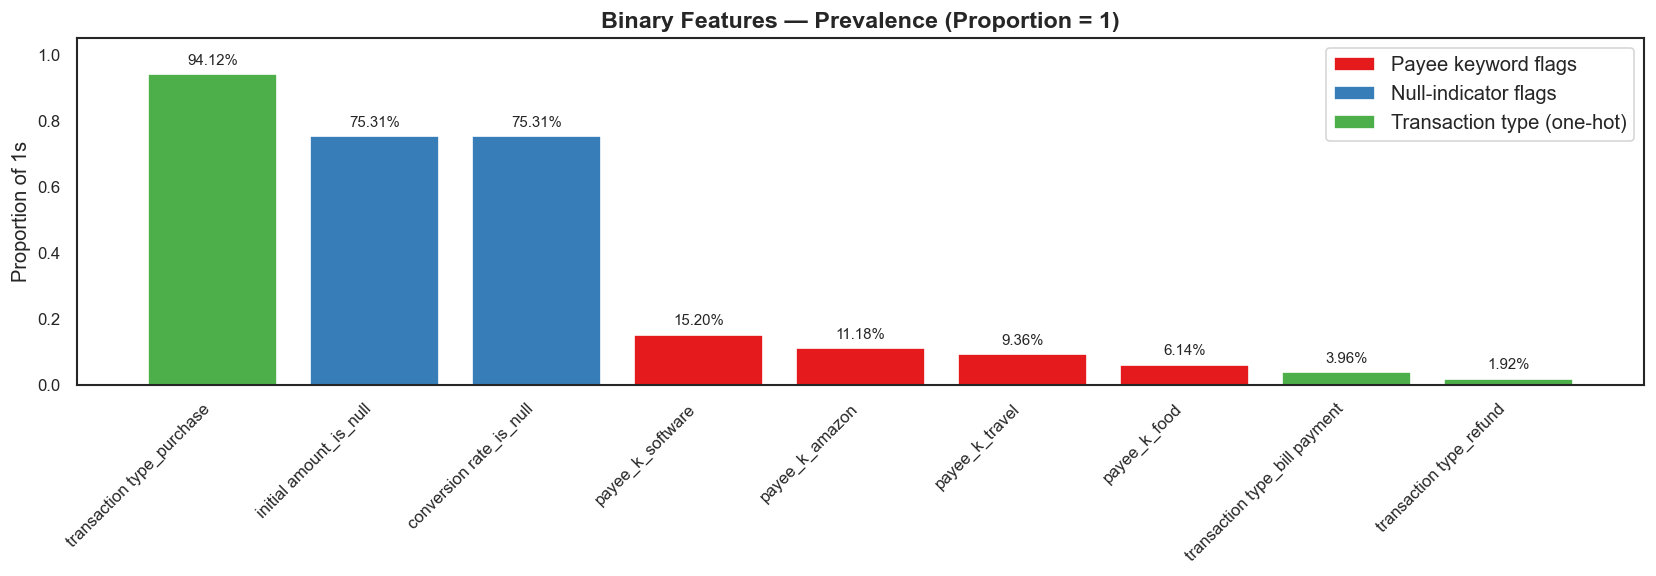

In [10]:
# ── Binary features — grouped bar chart ─────────────────────────────────────
binary_cols = BINARY_KEYWORD_FLAGS + BINARY_NULL_FLAGS + BINARY_TXN_TYPE
binary_summary = df[binary_cols].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors = []
for c in binary_summary.index:
    if c in BINARY_KEYWORD_FLAGS:
        colors.append(sns.color_palette("Set1")[0])   # red-ish
    elif c in BINARY_NULL_FLAGS:
        colors.append(sns.color_palette("Set1")[1])    # blue-ish
    else:
        colors.append(sns.color_palette("Set1")[2])    # green-ish

bars = ax.bar(range(len(binary_summary)), binary_summary.values, color=colors, edgecolor="white")
ax.set_xticks(range(len(binary_summary)))
ax.set_xticklabels(binary_summary.index, rotation=45, ha="right")
ax.set_ylabel("Proportion of 1s")
ax.set_title("Binary Features — Prevalence (Proportion = 1)", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.05)

for bar, val in zip(bars, binary_summary.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.2%}", ha="center", va="bottom", fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=sns.color_palette("Set1")[0], label="Payee keyword flags"),
    Patch(facecolor=sns.color_palette("Set1")[1], label="Null-indicator flags"),
    Patch(facecolor=sns.color_palette("Set1")[2], label="Transaction type (one-hot)"),
]
ax.legend(handles=legend_elements, loc="upper right")
plt.tight_layout()
plt.show()

## 5. Correlation Analysis — Feature-to-Feature

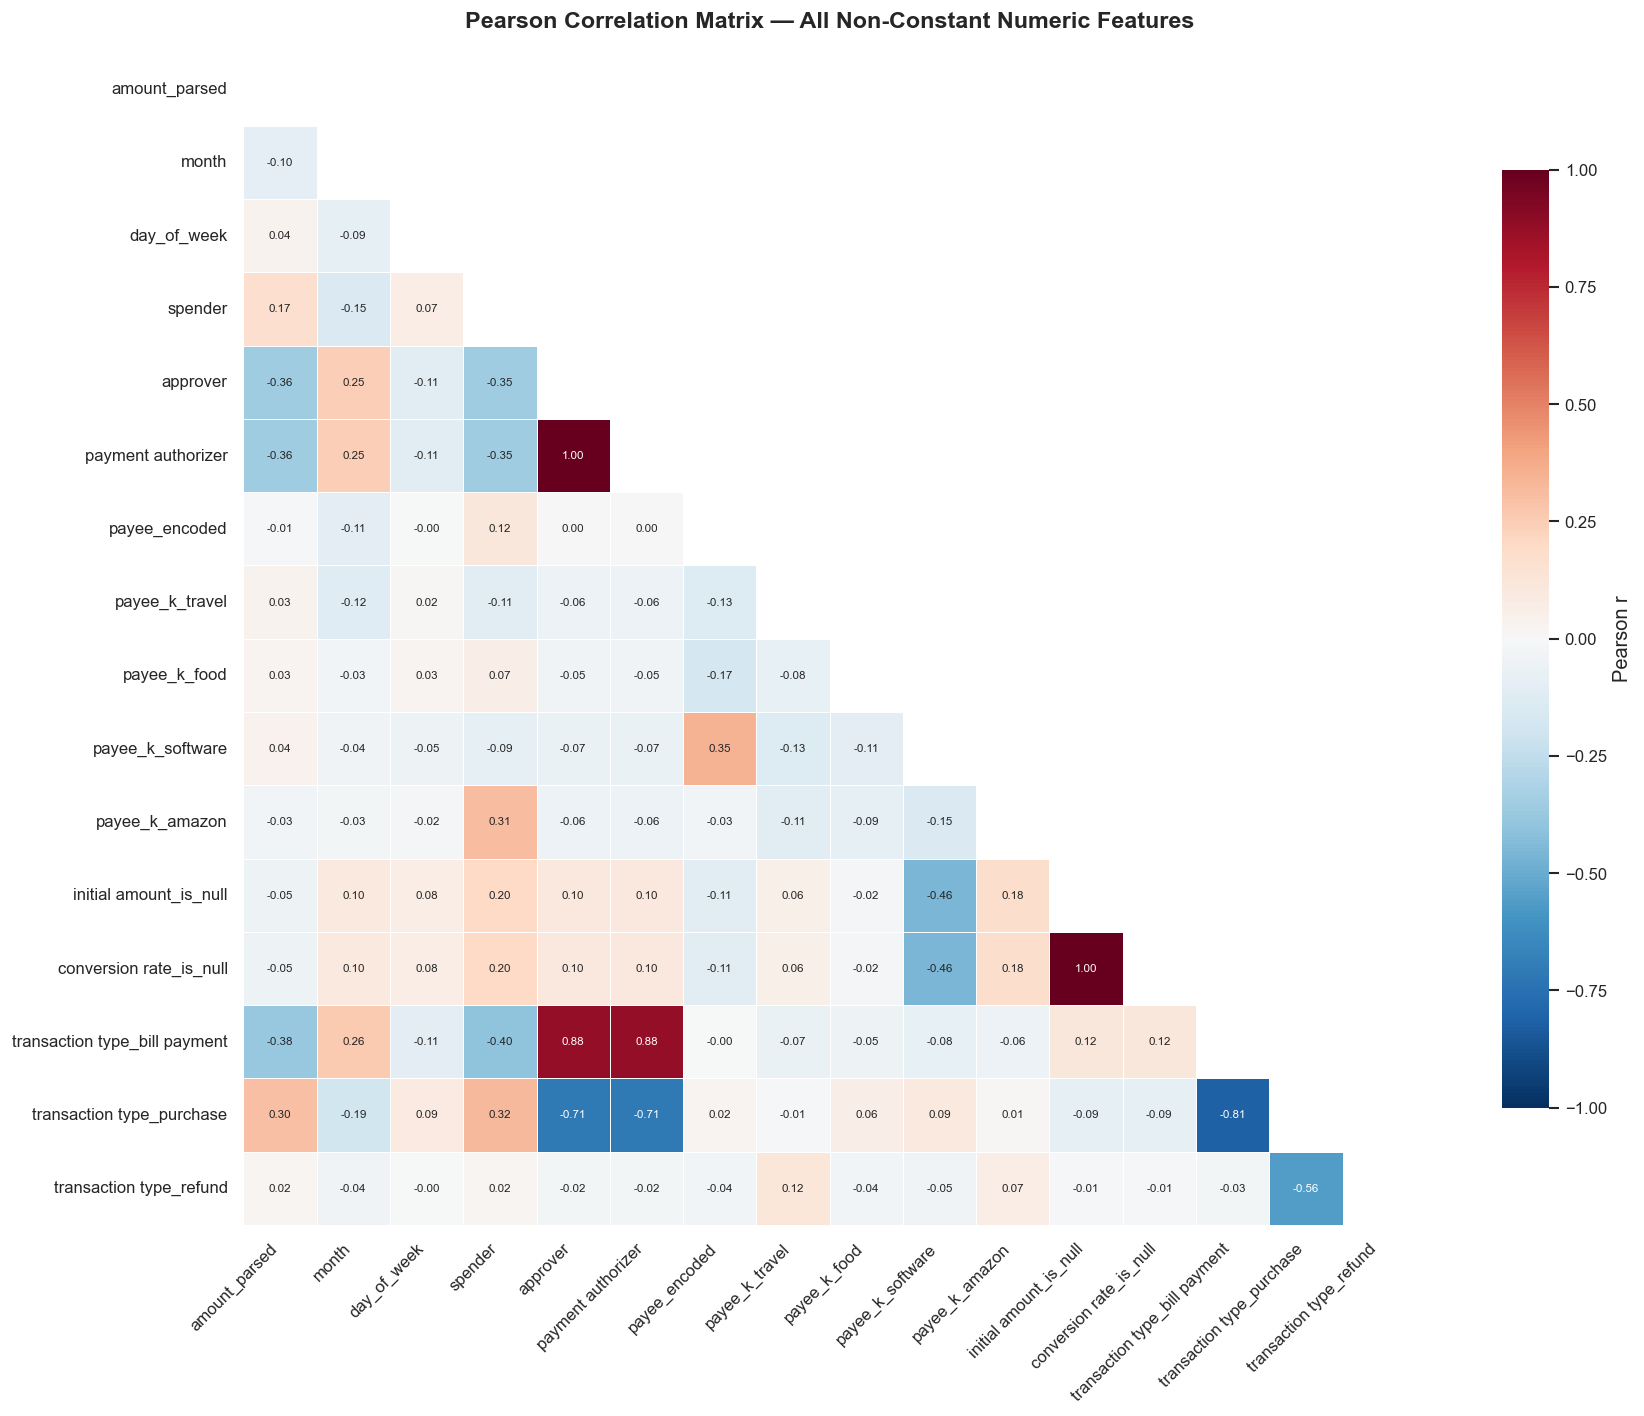

Notable correlations (|r| > 0.3):


,Feature 1,Feature 2,r
0,payment authorizer,approver,1.000
1,conversion rate_is_null,initial amount_is_null,1.000
2,transaction type_bill payment,payment authorizer,0.879
3,transaction type_bill payment,approver,0.879
4,transaction type_purchase,transaction type_bill payment,-0.813
5,transaction type_purchase,payment authorizer,-0.714
6,transaction type_purchase,approver,-0.714
7,transaction type_refund,transaction type_purchase,-0.559
8,initial amount_is_null,payee_k_software,-0.458
9,conversion rate_is_null,payee_k_software,-0.458


In [4]:
# ── Pearson correlation heatmap (all non-constant numeric features) ─────────
corr = df[ALL_NUMERIC].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={"size": 7}, vmin=-1, vmax=1,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)
ax.set_title("Pearson Correlation Matrix — All Non-Constant Numeric Features",
             fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Highlight strong correlations (|r| > 0.3)
strong = corr.where(~mask).stack().reset_index()
strong.columns = ["Feature 1", "Feature 2", "r"]
strong = strong[strong["r"].abs() > 0.3].sort_values("r", key=abs, ascending=False)
if len(strong):
    print("Notable correlations (|r| > 0.3):")
    display(strong.reset_index(drop=True).style.format({"r": "{:.3f}"}).background_gradient(
        cmap="RdBu_r", subset=["r"], vmin=-1, vmax=1))
else:
    print("No feature pairs with |r| > 0.3")

## 6. Correlation with GL Code — Numerical Input vs Categorical Target

For a **numerical feature vs categorical target**, we use:
- **Eta-squared (η²)**: proportion of variance in the numerical feature explained by group membership (ANOVA-based). Values range 0 → 1.
- **Box plots** per GL code to visualise the separation.

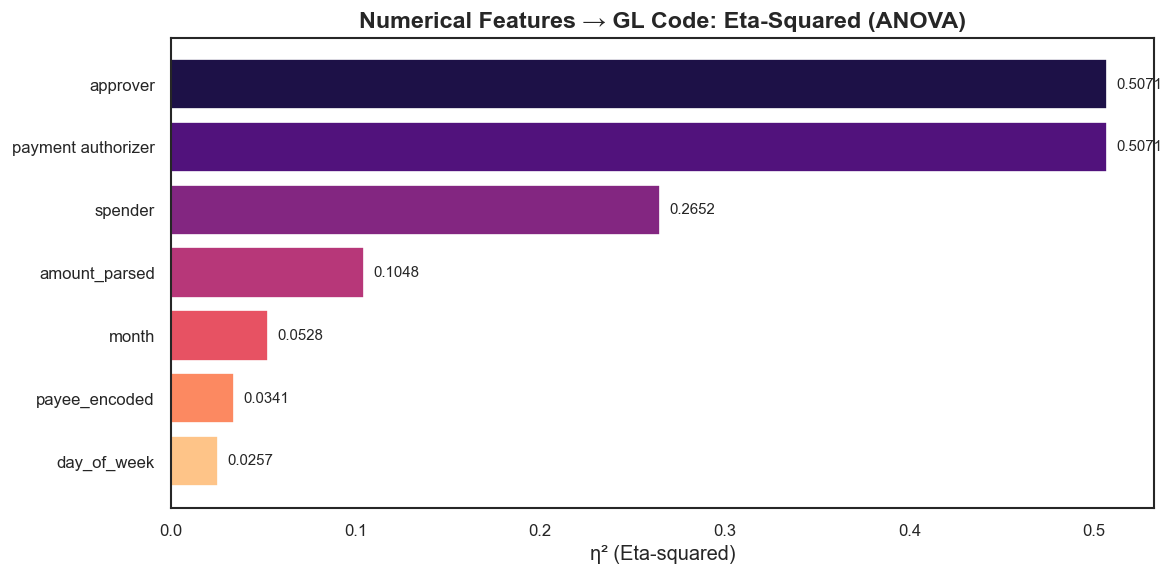

,eta_squared
approver,0.5071
payment authorizer,0.5071
spender,0.2652
amount_parsed,0.1048
month,0.0528
payee_encoded,0.0341
day_of_week,0.0257


In [5]:
# ── Eta-squared: numerical features vs gl_code ─────────────────────────────
def eta_squared(df, numeric_col, cat_col):
    """ANOVA-based eta-squared: SS_between / SS_total."""
    groups = [grp[numeric_col].dropna().values for _, grp in df.groupby(cat_col)]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        return 0.0
    f_stat, p_val = stats.f_oneway(*groups)
    grand_mean = df[numeric_col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((df[numeric_col] - grand_mean) ** 2).sum()
    return ss_between / ss_total if ss_total > 0 else 0.0

NUM_FEATURES_FOR_ETA = CONTINUOUS_FEATURES + ORDINAL_FEATURES + HASH_FEATURES + ENCODED_ID_FEATURES

eta_results = {col: eta_squared(df, col, TARGET) for col in NUM_FEATURES_FOR_ETA}
eta_df = pd.DataFrame.from_dict(eta_results, orient="index", columns=["eta_squared"]).sort_values("eta_squared", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(eta_df.index[::-1], eta_df["eta_squared"].values[::-1],
               color=sns.color_palette("magma", len(eta_df))[::-1], edgecolor="white")
ax.set_xlabel("η² (Eta-squared)")
ax.set_title("Numerical Features → GL Code: Eta-Squared (ANOVA)", fontsize=14, fontweight="bold")
for bar, val in zip(bars, eta_df["eta_squared"].values[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

display(eta_df.style.format("{:.4f}").background_gradient(cmap="magma", vmin=0, vmax=eta_df["eta_squared"].max()))

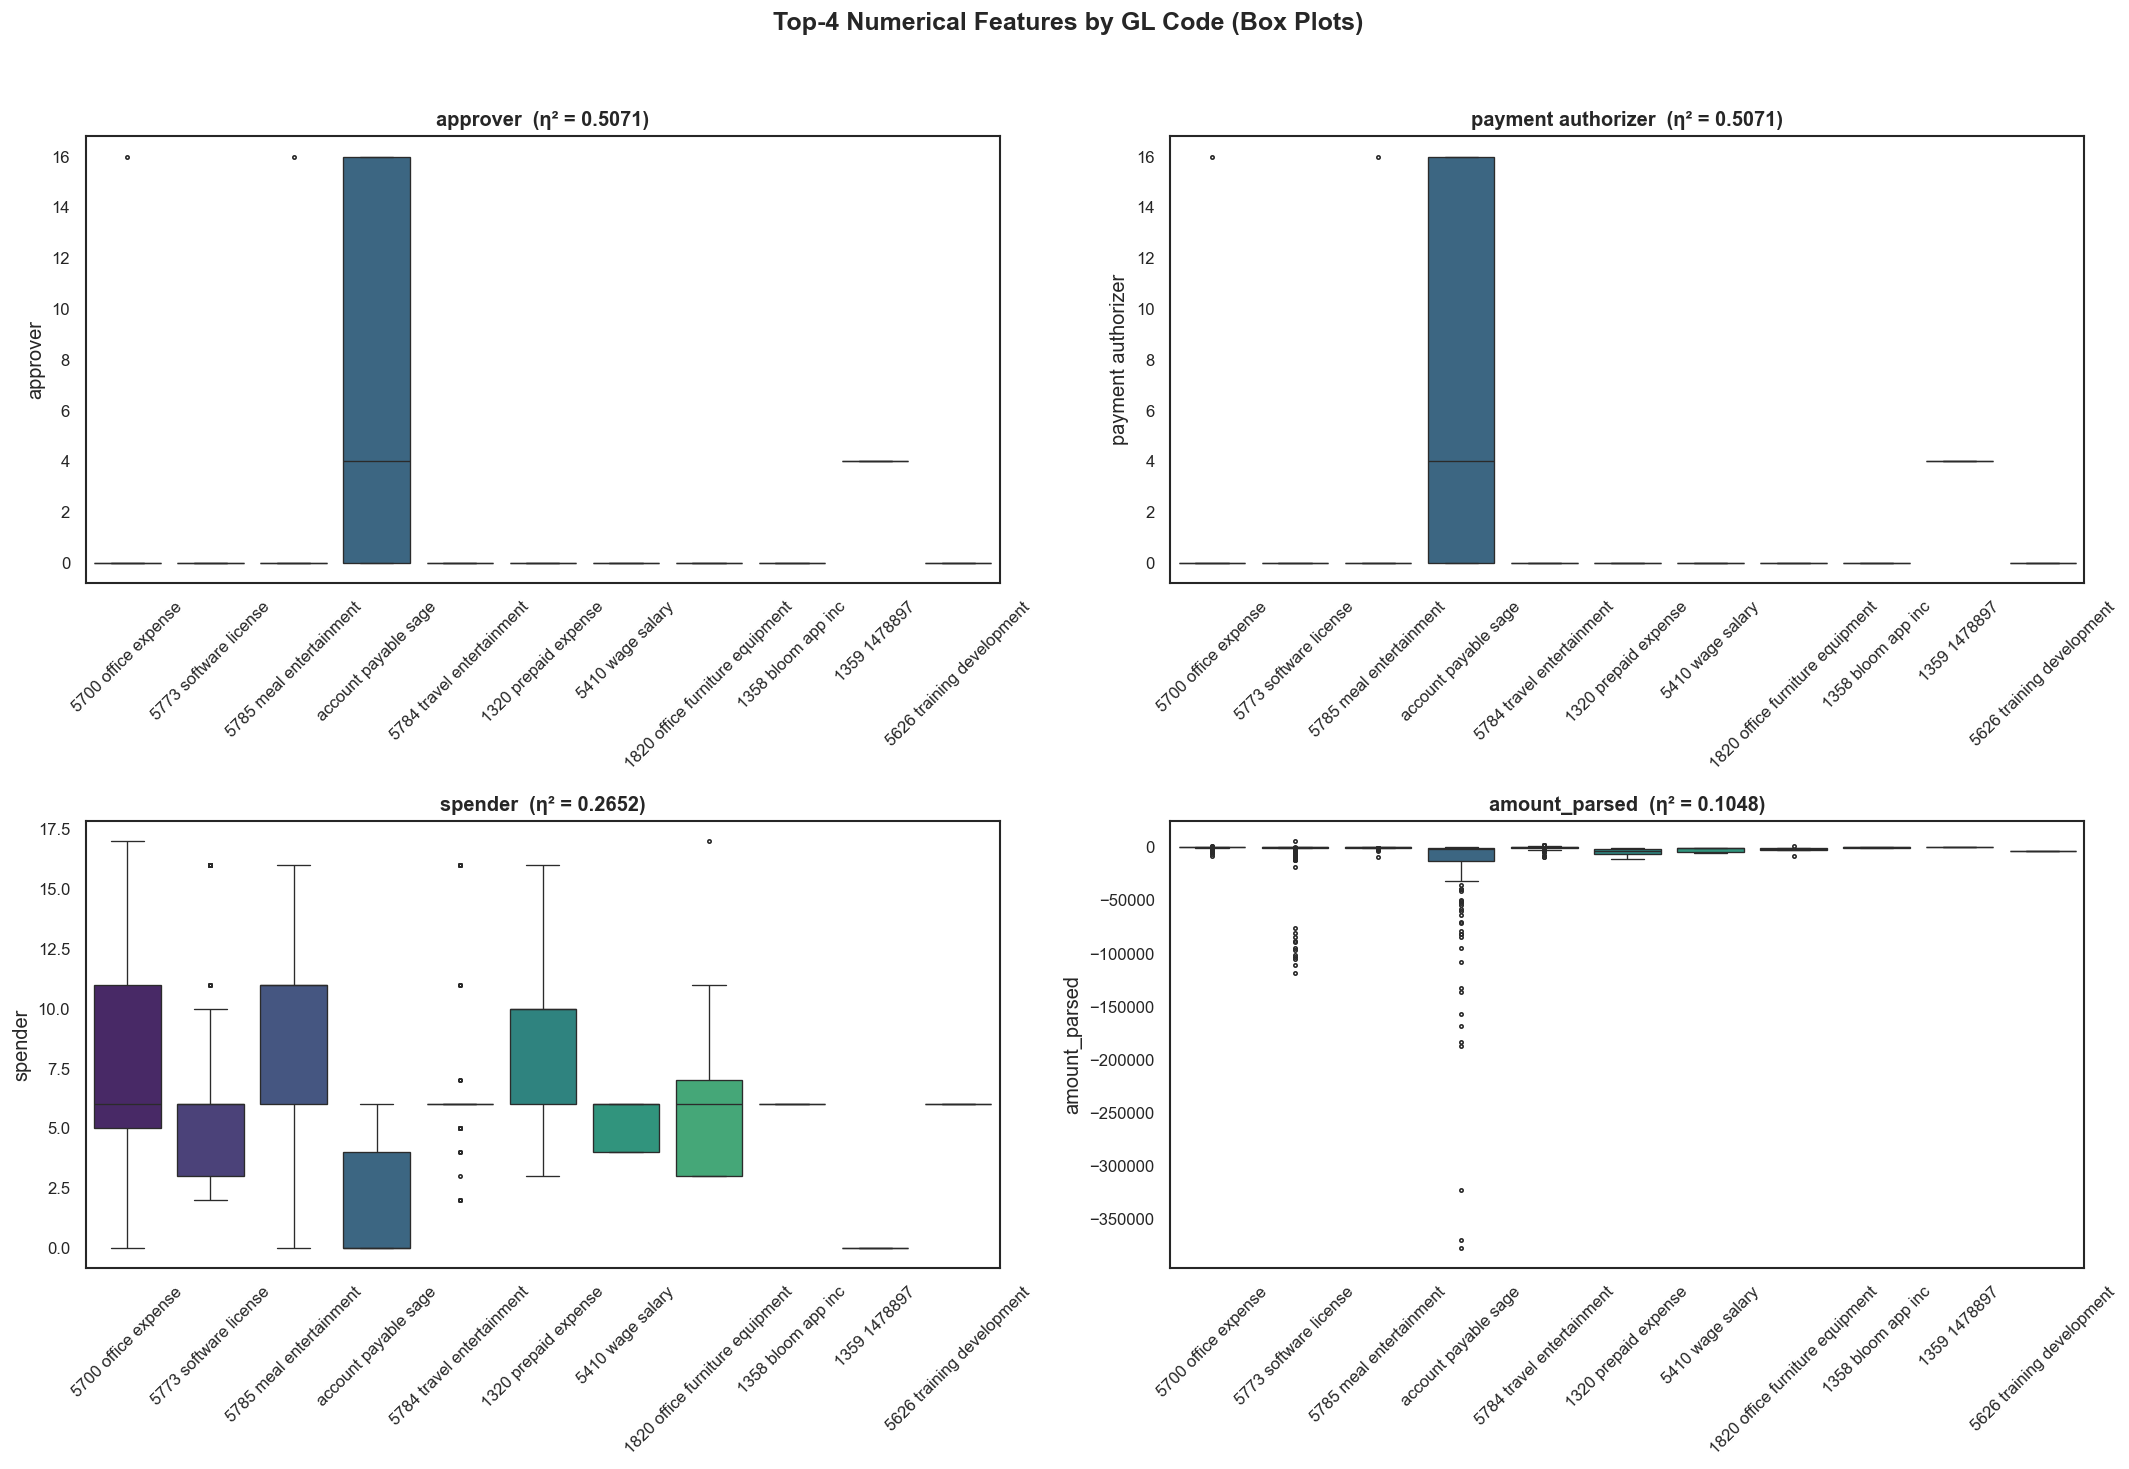

In [13]:
# ── Box plots: key numerical features by GL code ───────────────────────────
# Show top-4 numerical features by eta-squared
top_eta_features = eta_df.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

gl_order = df[TARGET].value_counts().index.tolist()

for ax, feat in zip(axes, top_eta_features):
    sns.boxplot(data=df, x=TARGET, y=feat, order=gl_order, ax=ax,
                palette="viridis", fliersize=2, linewidth=0.8)
    ax.set_title(f"{feat}  (η² = {eta_results[feat]:.4f})", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Top-4 Numerical Features by GL Code (Box Plots)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7. Correlation with GL Code — Categorical Input vs Categorical Target

For **categorical (incl. binary) input vs categorical target**, we use **Cramér's V** — a symmetric measure of association based on the chi-squared statistic. Values range 0 (no association) → 1 (perfect association).

We compute Cramér's V for:
- All binary features (keyword flags, null flags, transaction-type one-hot)
- Encoded-ID features (spender, approver, payment authorizer) treated as discrete categories

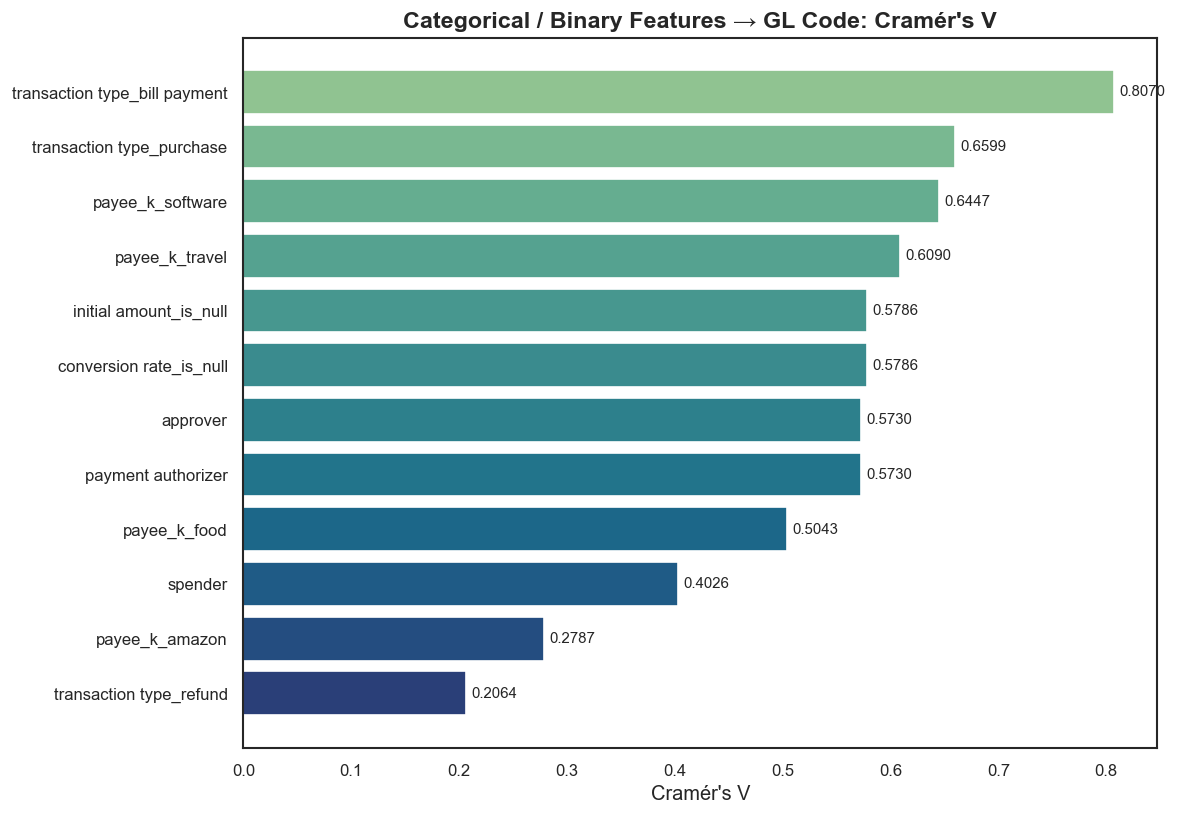

,cramers_v
transaction type_bill payment,0.8070
transaction type_purchase,0.6599
payee_k_software,0.6447
payee_k_travel,0.6090
initial amount_is_null,0.5786
conversion rate_is_null,0.5786
approver,0.5730
payment authorizer,0.5730
payee_k_food,0.5043
spender,0.4026


In [6]:
# ── Cramér's V: categorical / binary features vs gl_code ───────────────────
def cramers_v(x, y):
    """Bias-corrected Cramér's V."""
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    phi2 = chi2 / n
    # Bias correction
    phi2_corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0

CAT_FEATURES_FOR_V = ENCODED_ID_FEATURES + BINARY_FEATURES

cramers_results = {col: cramers_v(df[col], df[TARGET]) for col in CAT_FEATURES_FOR_V}
cramers_df = pd.DataFrame.from_dict(cramers_results, orient="index", columns=["cramers_v"]).sort_values("cramers_v", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(cramers_df.index[::-1], cramers_df["cramers_v"].values[::-1],
               color=sns.color_palette("crest", len(cramers_df))[::-1], edgecolor="white")
ax.set_xlabel("Cramér's V")
ax.set_title("Categorical / Binary Features → GL Code: Cramér's V", fontsize=14, fontweight="bold")
for bar, val in zip(bars, cramers_df["cramers_v"].values[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

display(cramers_df.style.format("{:.4f}").background_gradient(cmap="crest", vmin=0, vmax=cramers_df["cramers_v"].max()))

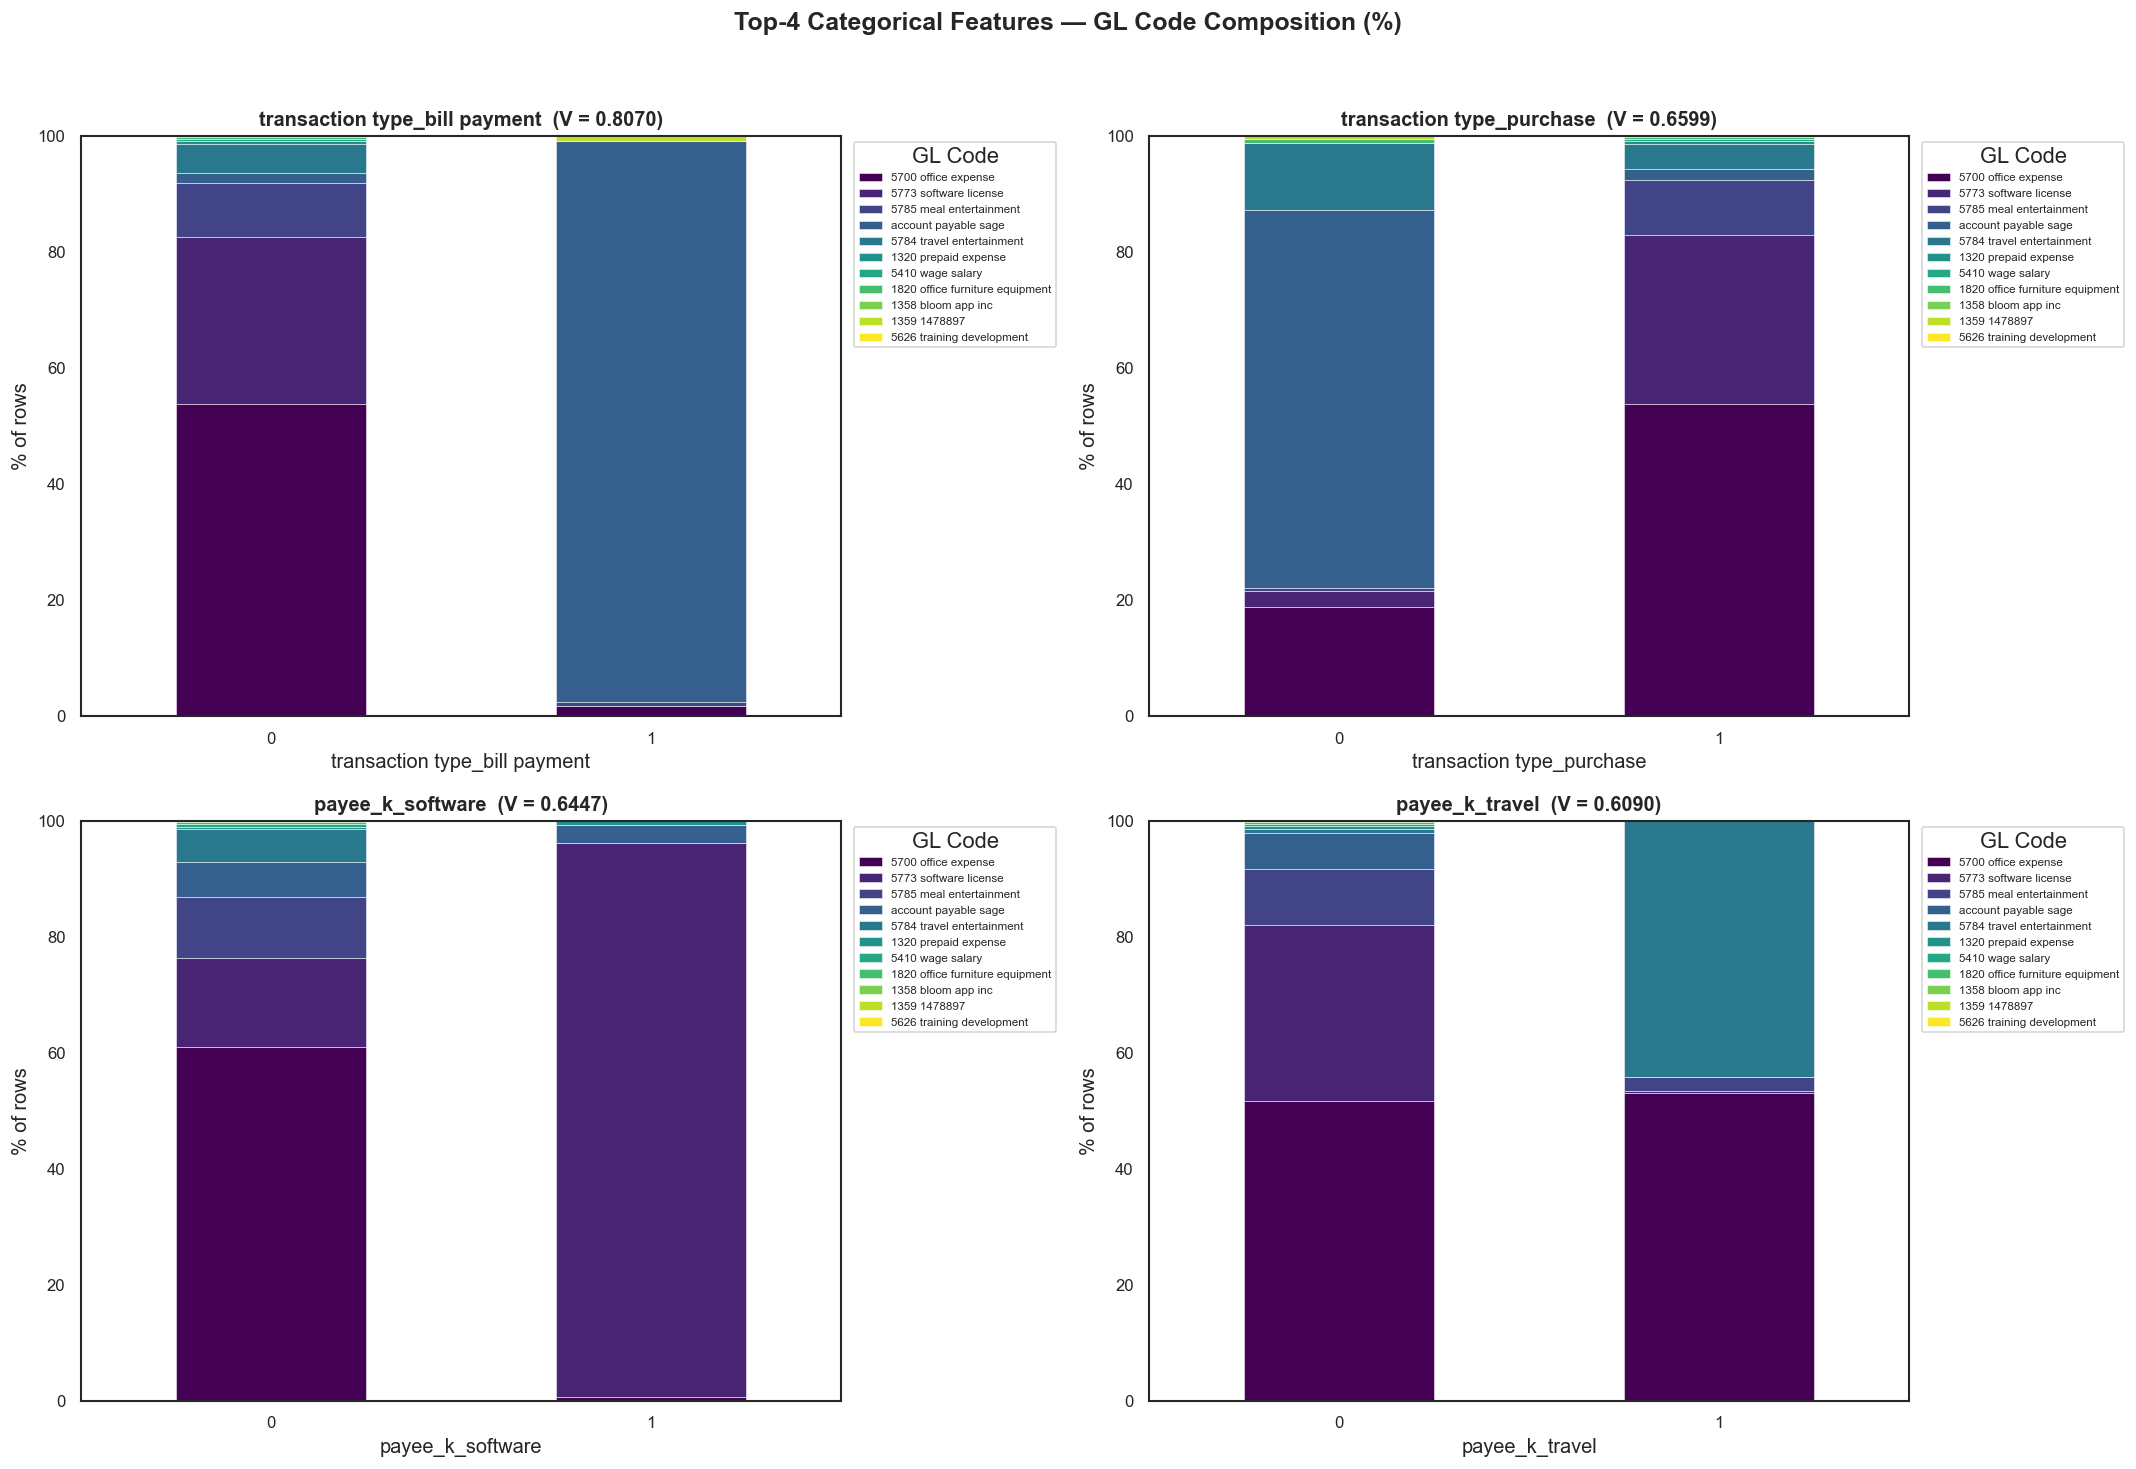

In [15]:
# ── Stacked bar: top-4 categorical features × GL code ──────────────────────
top_v_features = cramers_df.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

for ax, feat in zip(axes, top_v_features):
    ct = pd.crosstab(df[feat], df[TARGET], normalize="index") * 100
    ct = ct[gl_order]  # consistent GL-code ordering
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis", edgecolor="white", linewidth=0.3)
    ax.set_title(f"{feat}  (V = {cramers_results[feat]:.4f})", fontsize=12, fontweight="bold")
    ax.set_ylabel("% of rows")
    ax.set_xlabel(feat)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left", title="GL Code")

fig.suptitle("Top-4 Categorical Features — GL Code Composition (%)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8. Combined Feature Importance — All Features vs GL Code

A unified view of every feature's association strength with the target. Eta-squared is used for the continuous/ordinal features and Cramér's V for the categorical/binary features (both range 0 → 1).

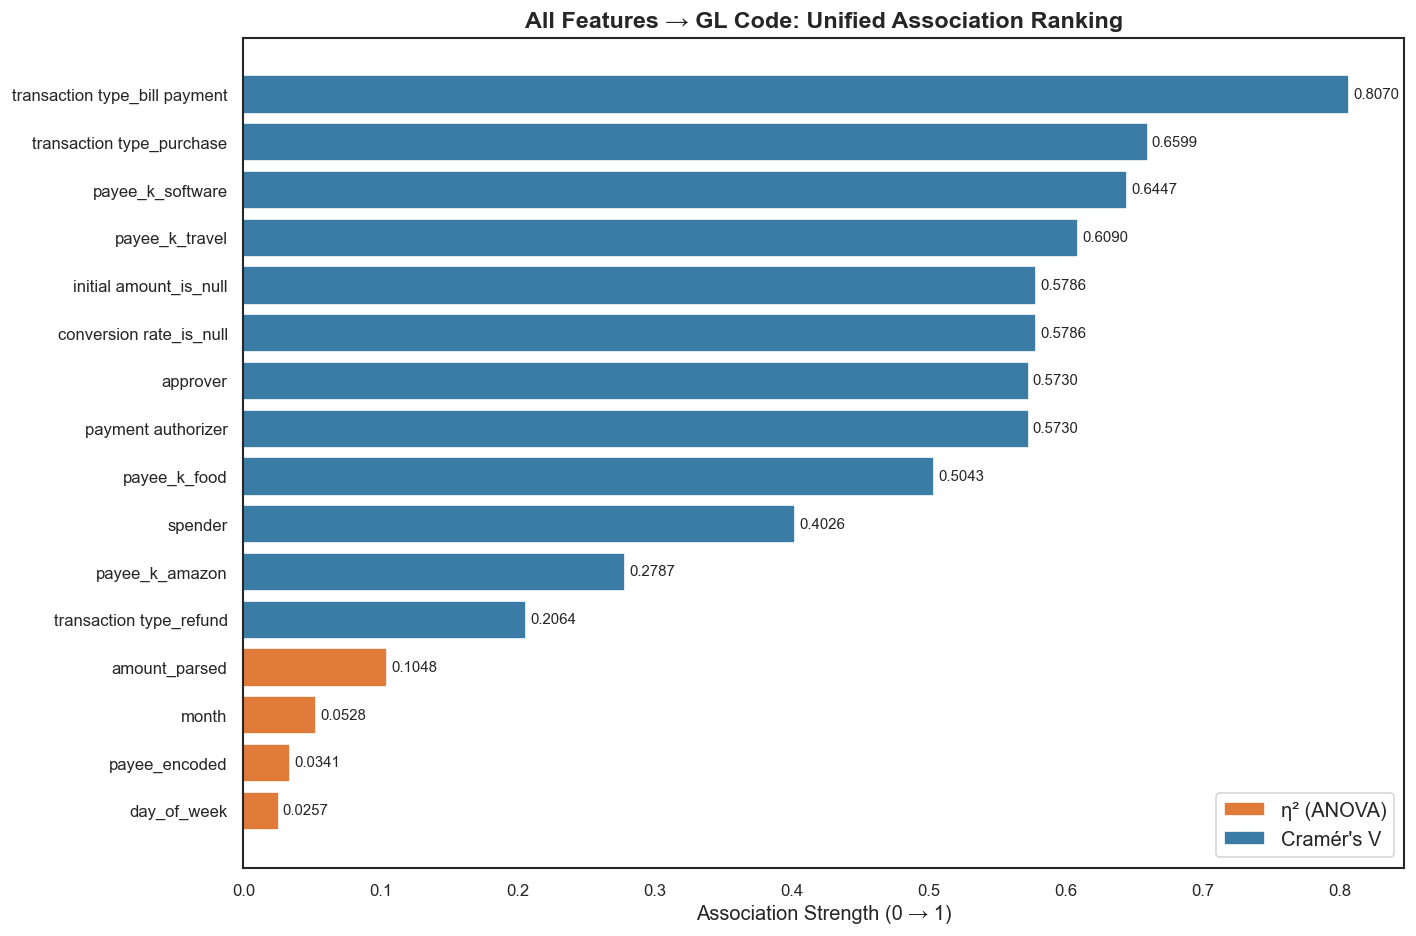

In [16]:
# ── Unified association strength: all features → gl_code ───────────────────
eta_rename = eta_df.rename(columns={"eta_squared": "association"})
eta_rename["measure"] = "η² (ANOVA)"

cramers_rename = cramers_df.rename(columns={"cramers_v": "association"})
cramers_rename["measure"] = "Cramér's V"

# Remove duplicates (encoded ID features appear in both — keep Cramér's V for them)
eta_only = eta_rename.loc[eta_rename.index.difference(cramers_rename.index)]
combined = pd.concat([eta_only, cramers_rename]).sort_values("association", ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
palette = {"η² (ANOVA)": "#E07B39", "Cramér's V": "#3A7CA5"}
bars = ax.barh(combined.index[::-1], combined["association"].values[::-1], edgecolor="white",
               color=[palette[m] for m in combined["measure"].values[::-1]])

ax.set_xlabel("Association Strength (0 → 1)")
ax.set_title("All Features → GL Code: Unified Association Ranking", fontsize=14, fontweight="bold")

for bar, val in zip(bars, combined["association"].values[::-1]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=v, label=k) for k, v in palette.items()], loc="lower right")
plt.tight_layout()
plt.show()

## 9. Per-GL-Code Feature Profiles

A heatmap showing the **mean value of each feature** within each GL code class. Features are z-score normalised across classes so differences stand out.

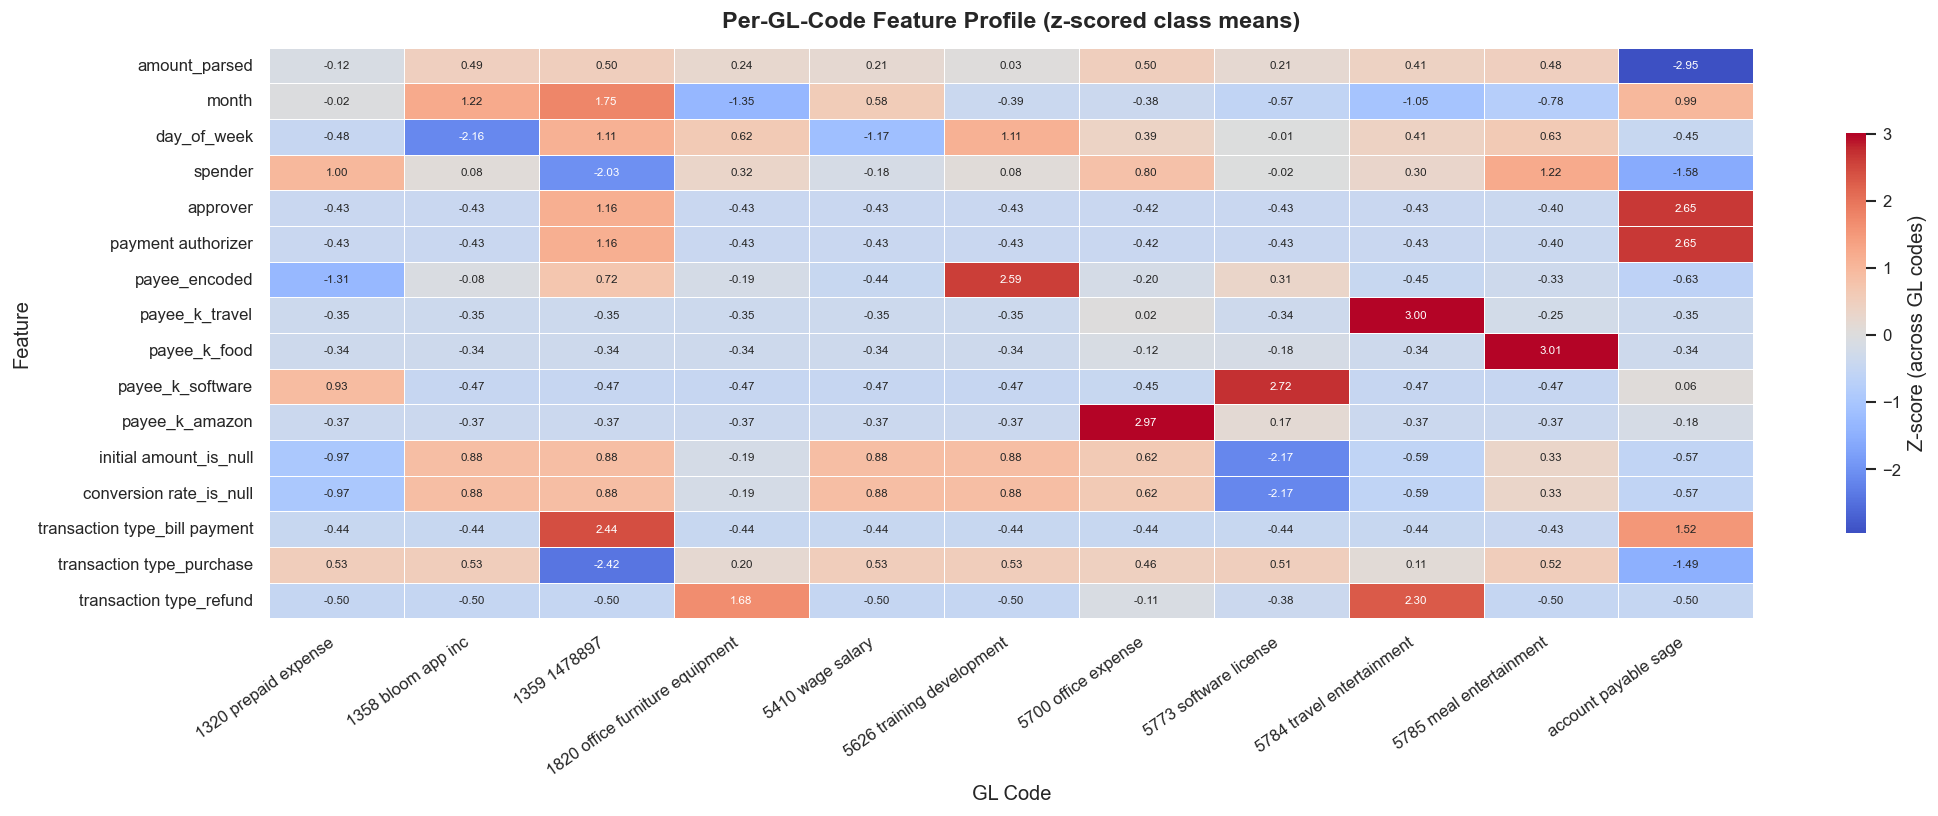

In [17]:
# ── Per-GL-code mean feature heatmap (z-scored) ────────────────────────────
group_means = df.groupby(TARGET)[ALL_NUMERIC].mean()
# Z-score normalise each feature across GL codes
group_z = (group_means - group_means.mean()) / group_means.std().replace(0, 1)

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    group_z.T, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    linewidths=0.5, ax=ax, annot_kws={"size": 7},
    cbar_kws={"shrink": 0.7, "label": "Z-score (across GL codes)"},
)
ax.set_title("Per-GL-Code Feature Profile (z-scored class means)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("GL Code")
ax.set_ylabel("Feature")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

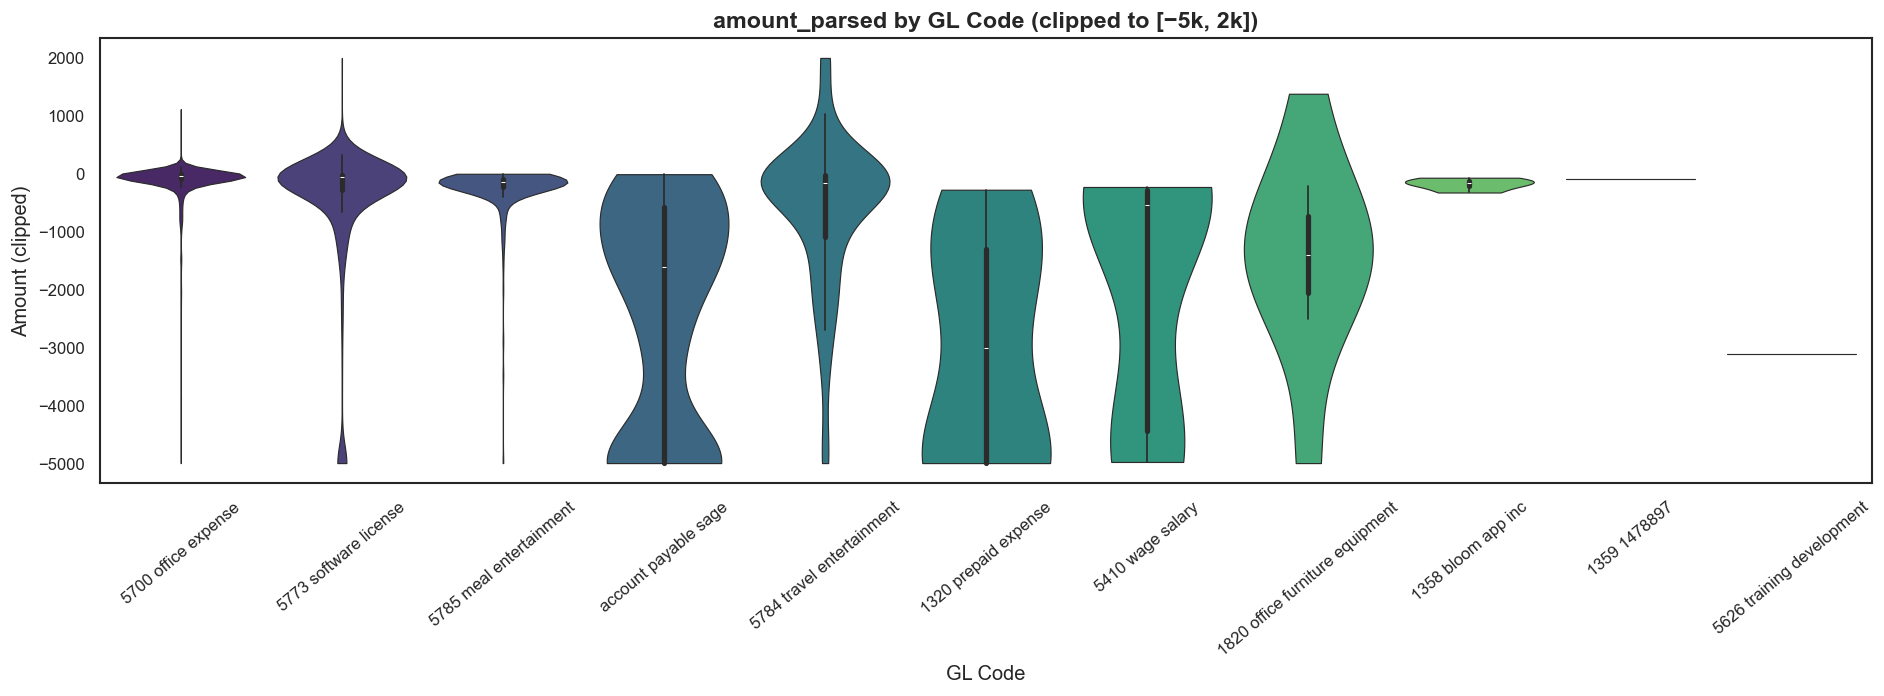

In [18]:
# ── Violin plot: amount_parsed per GL code ──────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
# Clip for readability
df_plot = df.copy()
df_plot["amount_clipped"] = df_plot["amount_parsed"].clip(-5000, 2000)

sns.violinplot(data=df_plot, x=TARGET, y="amount_clipped", order=gl_order,
               palette="viridis", inner="box", linewidth=0.7, ax=ax, cut=0)
ax.set_title("amount_parsed by GL Code (clipped to [−5k, 2k])", fontsize=14, fontweight="bold")
ax.set_xlabel("GL Code")
ax.set_ylabel("Amount (clipped)")
ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.show()

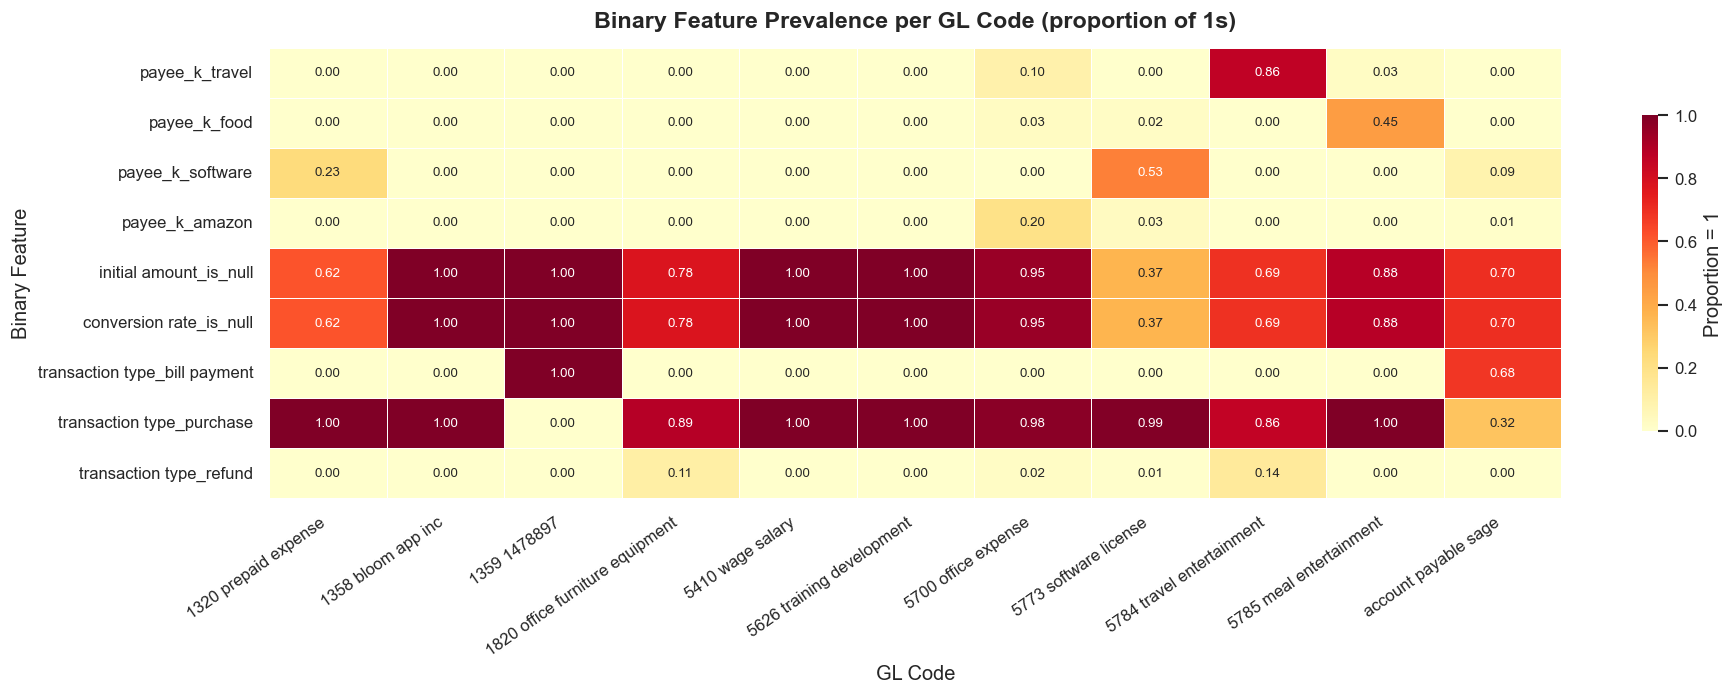

In [19]:
# ── Binary flag prevalence per GL code ──────────────────────────────────────
binary_by_gl = df.groupby(TARGET)[BINARY_FEATURES].mean()

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    binary_by_gl.T, annot=True, fmt=".2f", cmap="YlOrRd",
    linewidths=0.5, ax=ax, vmin=0, vmax=1,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.7, "label": "Proportion = 1"},
)
ax.set_title("Binary Feature Prevalence per GL Code (proportion of 1s)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("GL Code")
ax.set_ylabel("Binary Feature")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 10. Correlation-Based Feature Pruning Analysis

How many of the 16 non-constant manual features are **redundant** at various correlation thresholds?

We greedily remove features: for each highly-correlated pair (|r| ≥ threshold), drop the one
with lower association to GL code. Association is measured as:
- **η²** for numerical features (amount_parsed, month, day_of_week, payee_encoded, spender, approver, payment authorizer)
- **Cramér's V** for binary features

This mirrors the same analysis done for the 27 TF-IDF features.

Total non-constant features: 16

Greedy correlation-based pruning (drop feature with lower GL code association from each pair)



Threshold (|r|),Dropped,Kept,Dropped Features
0.950000,2,14,"conversion rate_is_null, payment authorizer"
0.900000,2,14,"conversion rate_is_null, payment authorizer"
0.850000,3,13,"approver, conversion rate_is_null, payment authorizer"
0.800000,4,12,"approver, conversion rate_is_null, payment authorizer, transaction type_purchase"
0.750000,4,12,"approver, conversion rate_is_null, payment authorizer, transaction type_purchase"
0.700000,4,12,"approver, conversion rate_is_null, payment authorizer, transaction type_purchase"
0.600000,4,12,"approver, conversion rate_is_null, payment authorizer, transaction type_purchase"
0.500000,4,12,"approver, conversion rate_is_null, payment authorizer, transaction type_purchase"



Detail at |r| ≥ 0.75 threshold:

  Dropped (4): ['approver', 'conversion rate_is_null', 'payment authorizer', 'transaction type_purchase']
  Kept    (12): ['amount_parsed', 'month', 'day_of_week', 'spender', 'payee_encoded', 'payee_k_travel', 'payee_k_food', 'payee_k_software', 'payee_k_amazon', 'initial amount_is_null', 'transaction type_bill payment', 'transaction type_refund']

  Correlated pairs triggering removal (|r| ≥ 0.75):
    approver                            ↔ payment authorizer                   |r|=1.000  → ✗ approver (assoc=0.5071)
    initial amount_is_null              ↔ conversion rate_is_null              |r|=1.000  → ✗ conversion rate_is_null (assoc=0.5786)
    approver                            ↔ transaction type_bill payment        |r|=0.879  → ✗ approver (assoc=0.5071)
    payment authorizer                  ↔ transaction type_bill payment        |r|=0.879  → ✗ payment authorizer (assoc=0.5071)
    transaction type_bill payment       ↔ transaction type_purchas

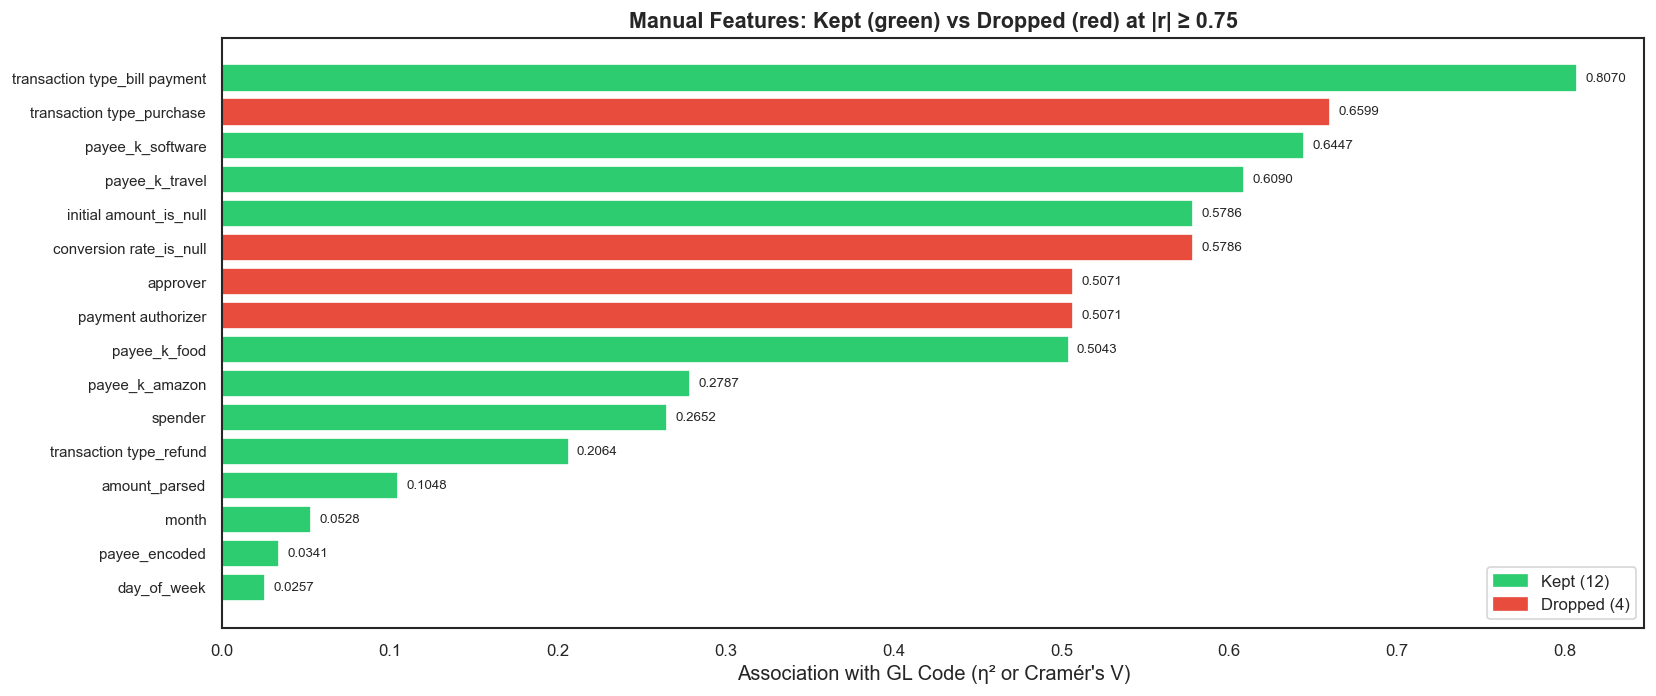

In [7]:
# ── Correlation-based pruning for manual features ───────────────────────────

# Build a unified association score for every non-constant feature
# η² for numerical features, Cramér's V for binary/categorical
assoc = {}
for f in ALL_NUMERIC:
    if f in eta_results:
        assoc[f] = eta_results[f]
    elif f in cramers_results:
        assoc[f] = cramers_results[f]
    else:
        assoc[f] = 0.0

corr_abs = df[ALL_NUMERIC].corr().abs()


def greedy_prune(corr_matrix, assoc_dict, threshold):
    """Greedily remove the less-associated feature from each pair with |r| >= threshold."""
    to_drop = set()
    features = list(corr_matrix.columns)
    for i in range(len(features)):
        if features[i] in to_drop:
            continue
        for j in range(i + 1, len(features)):
            if features[j] in to_drop:
                continue
            if corr_matrix.iloc[i, j] >= threshold:
                if assoc_dict.get(features[i], 0) < assoc_dict.get(features[j], 0):
                    to_drop.add(features[i])
                    break
                else:
                    to_drop.add(features[j])
    return to_drop


thresholds = [0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.60, 0.50]
results = []
for t in thresholds:
    dropped = greedy_prune(corr_abs, assoc, t)
    kept = [f for f in ALL_NUMERIC if f not in dropped]
    results.append({
        "Threshold (|r|)": t,
        "Dropped": len(dropped),
        "Kept": len(kept),
        "Dropped Features": ", ".join(sorted(dropped)) or "—",
    })

results_df = pd.DataFrame(results)
print(f"Total non-constant features: {len(ALL_NUMERIC)}\n")
print("Greedy correlation-based pruning (drop feature with lower GL code association from each pair)\n")
display(results_df.style.set_properties(**{"text-align": "left"}).hide(axis="index"))

# ── Detail at key thresholds ──
for thresh in [0.75, 0.50]:
    print(f"\n{'=' * 70}")
    print(f"Detail at |r| ≥ {thresh} threshold:")
    print("=" * 70)
    dropped_t = greedy_prune(corr_abs, assoc, thresh)
    kept_t = [f for f in ALL_NUMERIC if f not in dropped_t]
    print(f"\n  Dropped ({len(dropped_t)}): {sorted(dropped_t)}")
    print(f"  Kept    ({len(kept_t)}): {kept_t}")

    mask_upper = np.triu(np.ones_like(corr_abs, dtype=bool), k=1)
    pairs = corr_abs.where(mask_upper).stack().reset_index()
    pairs.columns = ["Feature A", "Feature B", "|r|"]
    pairs = pairs[pairs["|r|"] >= thresh].sort_values("|r|", ascending=False)
    if len(pairs):
        print(f"\n  Correlated pairs triggering removal (|r| ≥ {thresh}):")
        for _, row in pairs.iterrows():
            a, b, r = row["Feature A"], row["Feature B"], row["|r|"]
            if a in dropped_t:
                dropped_one, kept_one = a, b
            elif b in dropped_t:
                dropped_one, kept_one = b, a
            else:
                # Both kept (already handled by a different pair)
                continue
            print(f"    {a:35s} ↔ {b:35s}  |r|={r:.3f}  → ✗ {dropped_one} (assoc={assoc[dropped_one]:.4f})")

# ── Visual: kept vs dropped at |r| ≥ 0.75 ──
dropped_075 = greedy_prune(corr_abs, assoc, 0.75)
kept_075 = [f for f in ALL_NUMERIC if f not in dropped_075]

assoc_sorted = sorted(assoc.items(), key=lambda x: x[1], reverse=True)
names = [f for f, _ in assoc_sorted]
values = [v for _, v in assoc_sorted]
colors = ["#2ecc71" if f in kept_075 else "#e74c3c" for f in names]

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(names, values, color=colors, edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Association with GL Code (η² or Cramér's V)")
ax.set_title("Manual Features: Kept (green) vs Dropped (red) at |r| ≥ 0.75",
             fontsize=13, fontweight="bold")
ax.tick_params(axis="y", labelsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2ecc71", label=f"Kept ({len(kept_075)})"),
                   Patch(color="#e74c3c", label=f"Dropped ({len(dropped_075)})")],
          loc="lower right", fontsize=10)
for i, (name, val) in enumerate(zip(names, values)):
    ax.text(val + 0.005, i, f"{val:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()